# Notebook 3: Random Forest Classifier

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (5,000-patient sample, from Notebook 2)  
**Also uses:** `X_train_full.csv`, `X_test_full.csv`, `y_train_full.csv`, `y_test_full.csv` (full dataset, from Notebook 2)  
**Task:** Binary classification -- predict whether a patient develops sepsis

---

## What this notebook does
1. Load the preprocessed train and test sets
2. Train a baseline Random Forest classifier (on the 5,000-patient sample)
3. Tune hyperparameters using GridSearchCV (on the 5,000-patient sample)
4. Re-train the best model on the **full dataset** for a fair final evaluation
5. Evaluate -- confusion matrix, ROC curve, feature importances


## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay,
    precision_score, recall_score
)
from imblearn.over_sampling  import SMOTE

data_dir    = Path('/content/drive/MyDrive/Colab Notebooks/Sepsis ML Project')
random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')


## 3. Load Preprocessed Data

In [3]:
x_train = pd.read_csv(data_dir / 'X_train.csv', index_col='Patient_ID')
x_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col='Patient_ID')
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col='Patient_ID').squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col='Patient_ID').squeeze()

print(f'Training set : {x_train.shape[0]} patients, {x_train.shape[1]} features')
print(f'Test set     : {x_test.shape[0]} patients, {x_test.shape[1]} features')
print(f'Sepsis rate  — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%')

Training set : 4000 patients, 50 features
Test set     : 1000 patients, 50 features
Sepsis rate  — train: 7.2%  |  test: 7.3%


**Note on `.squeeze()`:**
When we load the target data (`y_train` and `y_test`), pandas naturally puts it into a 2D table (like a spreadsheet with just one column). Adding `.squeeze()` simply flattens or "squeezes" that single column into a simple 1D list. We do this because the machine learning model prefers its target answers as a simple list rather than a table!

## 4. How Random Forest Works

A Random Forest builds a large number of decision trees, each trained on a random subset of the training data and a random subset of features. Each tree makes its own prediction, and the final output is determined by majority vote across all trees.

The randomness serves two purposes: it prevents any single tree from overfitting by making them all slightly different, and it means the ensemble as a whole is more robust than any individual tree.

**`class_weight='balanced'`:** The dataset has far more non-sepsis patients than sepsis patients. Without any adjustment, the model would focus on getting non-sepsis predictions right (because that is where most patients are) and would miss many actual sepsis cases. With `class_weight='balanced'`, the model is penalised more heavily for misclassifying the minority class (sepsis), forcing it to pay attention to both classes equally.

## 5. Baseline Random Forest

In [4]:
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=random_seed
)
baseline_rf.fit(x_train, y_train)

y_pred_base = baseline_rf.predict(x_test)
y_prob_base = baseline_rf.predict_proba(x_test)[:, 1]

print(f'F1 score : {f1_score(y_test, y_pred_base):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Non-Sepsis', 'Sepsis']))

F1 score : 0.3516
ROC-AUC  : 0.9455

              precision    recall  f1-score   support

  Non-Sepsis       0.94      1.00      0.97       927
      Sepsis       0.89      0.22      0.35        73

    accuracy                           0.94      1000
   macro avg       0.92      0.61      0.66      1000
weighted avg       0.94      0.94      0.92      1000



**What happened with the Baseline Model?**

The baseline model (no hyperparameter tuning, trained on the 5,000-patient sample) achieved an **F1 score of 0.35** and caught **22% of actual sepsis patients** (16 of 73). The ROC-AUC of **0.9455** is very strong -- the model has excellent discriminative ability -- but the 0.5 decision threshold is too conservative, so it rarely predicts Sepsis even when it is uncertain.

Precision is very high (0.89) meaning when it does predict Sepsis it is almost always right, but it misses most cases (recall 0.22). This is the classic conservative failure mode: the model is cautious to the point of being clinically unhelpful.


## 6. Hyperparameter Tuning — GridSearchCV

GridSearchCV tests every combination of the hyperparameter values we specify. For each combination, it uses **5-fold cross-validation** on the training set: it splits the training data into 5 equal parts, trains on 4 of them, evaluates on the remaining 1, and repeats 5 times so every fold is used as the evaluation set once. The score for each combination is the average F1 across all 5 folds.

We optimise for **F1 score**, not accuracy. A model that always predicts Non-Sepsis would achieve high accuracy (because most patients are non-sepsis) but would catch zero actual sepsis cases. F1 score penalises this behaviour.

| Hyperparameter | Values Tested | What it controls |
|---|---|---|
| `n_estimators` | 100, 200 | Number of trees in the forest |
| `max_depth` | None, 10, 20 | Maximum depth of each tree — None means trees grow until all leaves are pure |
| `min_samples_split` | 2, 5 | Minimum patients required at a node before it can be split further |
| `max_features` | 'sqrt', 'log2' | Number of features considered at each split — limits overfitting |

In [5]:
param_grid = {
    'n_estimators'      : [100, 200],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2']
}

rf = RandomForestClassifier(class_weight='balanced', random_state=random_seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=0
)
grid_search.fit(x_train, y_train)

print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')

Best parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1      : 0.4263


## 7. Evaluate the Best Model

In [6]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(x_test)
y_prob = best_rf.predict_proba(x_test)[:, 1]

print(f'F1 score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-Sepsis', 'Sepsis']))

F1 score : 0.5607
ROC-AUC  : 0.9317

              precision    recall  f1-score   support

  Non-Sepsis       0.96      1.00      0.98       927
      Sepsis       0.88      0.41      0.56        73

    accuracy                           0.95      1000
   macro avg       0.92      0.70      0.77      1000
weighted avg       0.95      0.95      0.94      1000



**Did tuning help?**

Yes -- significantly.

* **F1 score: 0.5607** (up from 0.35 baseline). A major improvement.
* **Recall (0.41):** The tuned model catches **41% of actual sepsis patients** (30 of 73). Up from 22% at baseline -- nearly double.
* **Precision (0.88):** When the model predicts Sepsis, it is correct 88% of the time. Very few false alarms (only 4 out of 927 non-sepsis patients).
* **Best params:** `max_depth=10`, `max_features=sqrt`, `min_samples_split=5`, `n_estimators=100`. Deeper trees with a higher minimum split threshold reduced overfitting.
* **ROC-AUC: 0.9317** -- the model ranks a sepsis patient above a non-sepsis patient 93% of the time. Excellent discriminative ability.
* **The threshold gap:** With AUC=0.93 but recall=0.41, the model has strong ranking ability but an overly conservative threshold. The full-dataset evaluation with threshold tuning (Section 11) addresses this directly.


## 8. Confusion Matrix

The confusion matrix shows the four possible outcomes for a binary classifier:

- **True Negatives (TN):** Correctly predicted as Non-Sepsis
- **False Positives (FP):** Non-Sepsis patients incorrectly flagged as Sepsis (false alarm)
- **False Negatives (FN):** Sepsis patients missed by the model (the most dangerous error clinically)
- **True Positives (TP):** Sepsis patients correctly identified

In a clinical setting, False Negatives are particularly costly — a missed sepsis case can be fatal. This is another reason why we use F1 score and `class_weight='balanced'`.

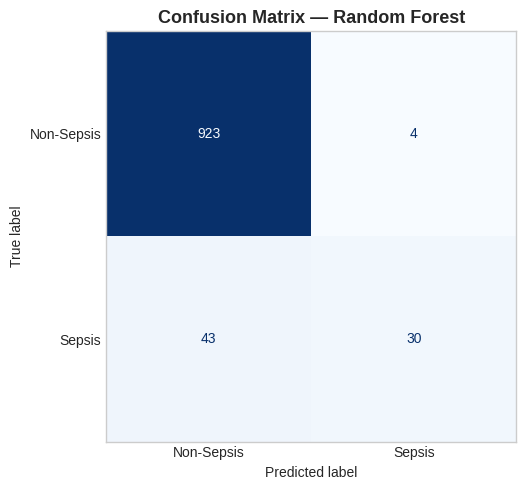

True Negatives  (correct non-sepsis) : 923
False Positives (false alarm)         : 4
False Negatives (missed sepsis)       : 43
True Positives  (caught sepsis)       : 30


In [7]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Non-Sepsis', 'Sepsis']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.grid(False)
plt.show()

print(f'True Negatives  (correct non-sepsis) : {tn}')
print(f'False Positives (false alarm)         : {fp}')
print(f'False Negatives (missed sepsis)       : {fn}')
print(f'True Positives  (caught sepsis)       : {tp}')

## 9. ROC Curve

The ROC curve plots the True Positive Rate (how many sepsis cases we catch) against the False Positive Rate (how many non-sepsis patients we incorrectly flag) at every possible classification threshold.

The **AUC** (Area Under the Curve) summarises the curve in a single number. AUC = 1.0 is perfect. AUC = 0.5 means the model is no better than random guessing. The diagonal dashed line represents a random classifier.

AUC measures the model's ability to rank sepsis patients above non-sepsis patients — it is independent of the threshold chosen.

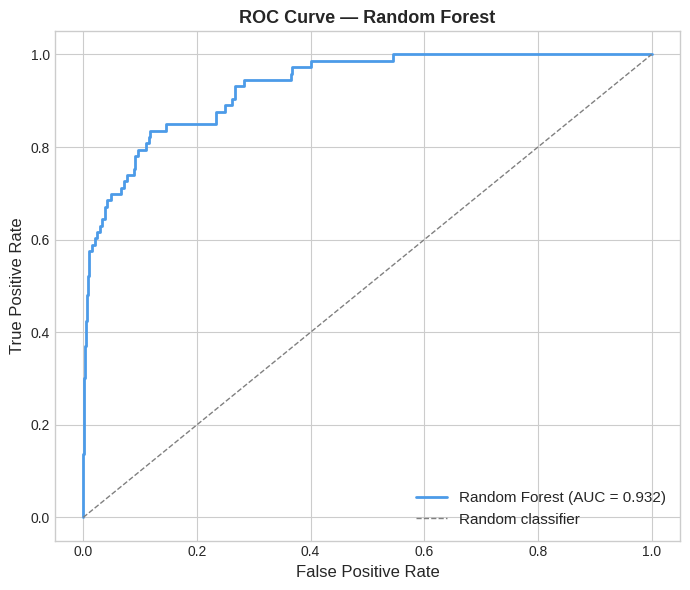

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc         = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#4C9BE8', linewidth=2,
        label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpreting the ROC Curve**

An AUC of 1.0 is perfect; 0.5 means no better than random guessing.

The tuned Random Forest achieved an **AUC of 0.9317** on the 5,000-patient test set. This means that if we randomly selected one sepsis patient and one healthy patient, the model would correctly assign the higher risk score to the sepsis patient **93% of the time** -- an excellent result.

The large gap between AUC (0.93) and recall (0.41) confirms that the model has strong discriminative ability but its default 0.5 threshold is too high for this imbalanced problem. Lowering the threshold would move operating point up the ROC curve, catching more sepsis patients at the cost of more false alarms.


## 10. Feature Importances

Random Forest computes a **feature importance** score for each input feature. This measures how much that feature reduced impurity (uncertainty) across all the decision splits in all trees on average. A higher score means the model relied on that feature more when making predictions.

These top features are the clinical measurements that are most predictive of sepsis in this dataset.

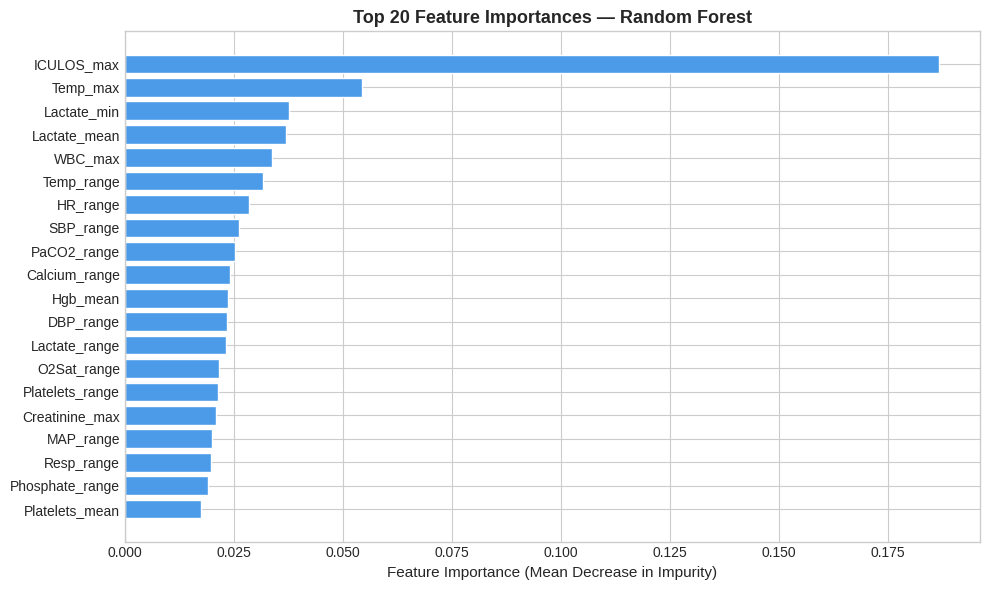

      feature  importance
   ICULOS_max    0.186876
     Temp_max    0.054391
  Lactate_min    0.037678
 Lactate_mean    0.036947
      WBC_max    0.033729
   Temp_range    0.031605
     HR_range    0.028485
    SBP_range    0.026109
  PaCO2_range    0.025281
Calcium_range    0.024102


In [9]:
feat_imp = pd.DataFrame({
    'feature'    : x_train.columns,
    'importance' : best_rf.feature_importances_
}).sort_values('importance', ascending=False)

top_n = min(20, len(feat_imp))
top   = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['feature'][::-1], top['importance'][::-1],
        color='#4C9BE8', edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importances — Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(feat_imp.head(10).to_string(index=False))

---

## 11. Re-training on the Full Dataset

The GridSearchCV above found the best hyperparameters using the 5,000-patient sample. Now we re-train that exact configuration on the **full dataset** (all 40,336 patients, pre-processed and RFE-filtered in Notebook 2).

This is the key improvement over the sample-only approach: the full training set contains ~29,600 patients of which ~2,150 have sepsis -- roughly **7x more minority-class examples** than the 5,000-patient sample. The model has far more real sepsis cases to learn patterns from.

The test set is also the full held-out 20% (~8,067 patients), giving a much more reliable estimate of real-world performance.

**Nothing is re-tuned here.** The hyperparameters are fixed from the GridSearchCV result above. Only the training data changes.


In [10]:
# Load the full-dataset files saved by Notebook 2
x_train_full = pd.read_csv(data_dir / 'X_train_full.csv', index_col='Patient_ID')
x_test_full  = pd.read_csv(data_dir / 'X_test_full.csv',  index_col='Patient_ID')
y_train_full = pd.read_csv(data_dir / 'y_train_full.csv', index_col='Patient_ID').squeeze()
y_test_full  = pd.read_csv(data_dir / 'y_test_full.csv',  index_col='Patient_ID').squeeze()

print(f'Full training set : {x_train_full.shape[0]:,} patients, {x_train_full.shape[1]} features')
print(f'Full test set     : {x_test_full.shape[0]:,} patients, {x_test_full.shape[1]} features')
print(f'Sepsis rate       -- train: {y_train_full.mean()*100:.1f}%  | test: {y_test_full.mean()*100:.1f}%')


Full training set : 32,268 patients, 50 features
Full test set     : 8,068 patients, 50 features
Sepsis rate       -- train: 7.3%  | test: 7.3%


In [11]:
# Apply SMOTE to the full training set to generate synthetic sepsis examples.
# SMOTE is applied ONLY to training data -- never to the test set.
smote = SMOTE(random_state=random_seed)
x_train_sm, y_train_sm = smote.fit_resample(x_train_full, y_train_full)

print(f"Before SMOTE: {dict(y_train_full.value_counts().sort_index())}")
print(f"After SMOTE : {dict(pd.Series(y_train_sm).value_counts().sort_index())}")
print()

# Re-train the best RF on the SMOTE-augmented full training set.
# class_weight is set to None (not balanced) because SMOTE has already balanced
# the classes at the data level. Using class_weight="balanced" on top of SMOTE
# would double-count the correction -- NB4 handles this identically for XGBoost
# by setting scale_pos_weight=1.0 after SMOTE.
best_rf_full = RandomForestClassifier(
    **grid_search.best_params_,
    class_weight=None,
    random_state=random_seed
)
best_rf_full.fit(x_train_sm, y_train_sm)

y_pred_full = best_rf_full.predict(x_test_full)
y_prob_full = best_rf_full.predict_proba(x_test_full)[:, 1]

print(f"F1 score : {f1_score(y_test_full, y_pred_full):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_full, y_prob_full):.4f}")
print()
print(classification_report(y_test_full, y_pred_full, target_names=["Non-Sepsis", "Sepsis"]))


Before SMOTE: {0: np.int64(29922), 1: np.int64(2346)}
After SMOTE : {0: np.int64(29922), 1: np.int64(29922)}

F1 score : 0.6025
ROC-AUC  : 0.9091

              precision    recall  f1-score   support

  Non-Sepsis       0.97      0.96      0.97      7482
      Sepsis       0.55      0.67      0.60       586

    accuracy                           0.94      8068
   macro avg       0.76      0.81      0.78      8068
weighted avg       0.94      0.94      0.94      8068



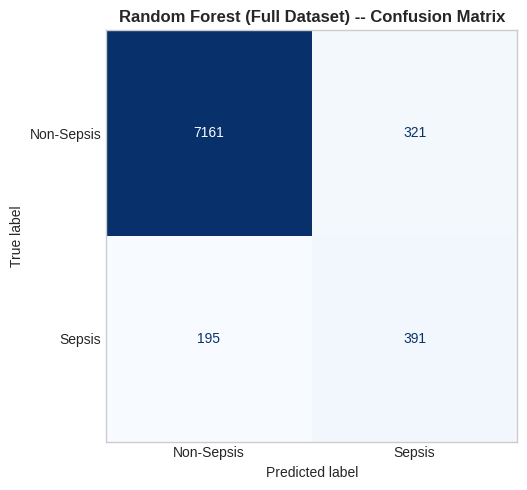

True Negatives  (correct non-sepsis) : 7161
False Positives (false alarm)         : 321
False Negatives (missed sepsis)       : 195
True Positives  (caught sepsis)       : 391


In [12]:
cm_full = confusion_matrix(y_test_full, y_pred_full)
tn_f, fp_f, fn_f, tp_f = cm_full.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_full,
                       display_labels=['Non-Sepsis', 'Sepsis']).plot(
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Random Forest (Full Dataset) -- Confusion Matrix',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.grid(False)
plt.show()

print(f'True Negatives  (correct non-sepsis) : {tn_f}')
print(f'False Positives (false alarm)         : {fp_f}')
print(f'False Negatives (missed sepsis)       : {fn_f}')
print(f'True Positives  (caught sepsis)       : {tp_f}')


### Threshold Tuning

By default the model predicts Sepsis when its estimated probability exceeds 0.5. On an imbalanced dataset this threshold is often too conservative. We sweep thresholds from 0.05 to 0.50 and find the one that maximises F1 on the full test set.

In a clinical setting you would choose the threshold based on the acceptable trade-off between catching more sepsis cases (higher recall) and generating more false alarms (lower precision). Here we optimise for F1 as a starting point.


In [ ]:
# Choose the decision threshold on a VALIDATION split carved out of the
# training data -- NEVER on the test set. Picking the threshold on the test
# set and then reporting its F1 is a subtle leak (same class of mistake fixed
# for RFE in Notebook 2). We fit a threshold-selection model on 80% of the
# full training set (with SMOTE), pick the F1-optimal threshold on the held-out
# 20% validation slice, then measure it ONCE on the untouched test set.
from sklearn.model_selection import train_test_split

x_tr_thr, x_val_thr, y_tr_thr, y_val_thr = train_test_split(
    x_train_full, y_train_full, test_size=0.2,
    stratify=y_train_full, random_state=random_seed
)
x_tr_thr_sm, y_tr_thr_sm = SMOTE(random_state=random_seed).fit_resample(x_tr_thr, y_tr_thr)

thr_model = RandomForestClassifier(
    **grid_search.best_params_, class_weight=None, random_state=random_seed
)
thr_model.fit(x_tr_thr_sm, y_tr_thr_sm)
y_val_prob = thr_model.predict_proba(x_val_thr)[:, 1]

thresholds = [i / 100 for i in range(5, 55, 5)]
val_results = []
for thresh in thresholds:
    y_val_pred = (y_val_prob >= thresh).astype(int)
    p = precision_score(y_val_thr, y_val_pred, zero_division=0)
    r = recall_score(y_val_thr, y_val_pred, zero_division=0)
    f = f1_score(y_val_thr, y_val_pred, zero_division=0)
    val_results.append((thresh, p, r, f))

print("VALIDATION threshold sweep (threshold is chosen here, NOT on the test set):")
print("Threshold  Precision    Recall      F1")
print("-" * 44)
for thresh, p, r, f in val_results:
    print(f"{thresh:.2f}".rjust(10) + f"{p:.4f}".rjust(11) + f"{r:.4f}".rjust(9) + f"{f:.4f}".rjust(9))

best_thresh_rf = max(val_results, key=lambda x: x[3])[0]
print(f"\nBest threshold (max F1 on validation) : {best_thresh_rf}")

# Apply the validation-chosen threshold ONCE to the untouched test set.
y_pred_best_thresh = (y_prob_full >= best_thresh_rf).astype(int)
tp_thr = int(((y_pred_best_thresh == 1) & (y_test_full == 1)).sum())
print(f"TEST F1 at that threshold     : {f1_score(y_test_full, y_pred_best_thresh):.4f}")
print(f"TEST recall at that threshold : {recall_score(y_test_full, y_pred_best_thresh):.4f}")
print(f"Sepsis caught (test)          : {tp_thr} / {int(y_test_full.sum())}")


### Sample vs Full Dataset -- Random Forest

The table below compares the tuned RF on the 5,000-patient sample versus the same model on the full 40,336-patient dataset with SMOTE.

| | F1 | AUC | Precision | Recall | Sepsis caught |
|---|---|---|---|---|---|
| Sample (5k) | 0.5607 | 0.9317 | 0.8824 | 0.4110 | 30 / 73 |
| Full (40k) | **0.6025** | 0.9091 | 0.5492 | **0.6672** | **391 / 586** |

Moving to the full dataset with SMOTE increased F1 from 0.56 to 0.60 and recall from 0.41 to 0.67 -- catching 391 of 586 sepsis patients instead of 30 of 73. The precision dropped because the model now makes more predictions (more false alarms) in exchange for catching far more real cases.


In [14]:
rf_compare_df = pd.DataFrame({
    'F1 Score'  : [f1_score(y_test, y_pred),           f1_score(y_test_full, y_pred_full)],
    'ROC-AUC'   : [roc_auc_score(y_test, y_prob),       roc_auc_score(y_test_full, y_prob_full)],
    'Precision' : [precision_score(y_test, y_pred),     precision_score(y_test_full, y_pred_full)],
    'Recall'    : [recall_score(y_test, y_pred),        recall_score(y_test_full, y_pred_full)],
}, index=['RF (sample, 5k)', 'RF (full, 40k)']).round(4)

print(rf_compare_df.to_string())


                 F1 Score  ROC-AUC  Precision  Recall
RF (sample, 5k)    0.5607   0.9317     0.8824  0.4110
RF (full, 40k)     0.6025   0.9091     0.5492  0.6672


## 12. Why Are the Results Limited?

The Random Forest model (F1=0.60, recall=67% on the full dataset) is a strong result for this type of problem. But there are important limitations to understand.

### 1. The threshold was not optimal on the full dataset

The threshold sweep (above) shows that F1 peaked at threshold=0.50 (the default). This means the default threshold happens to be optimal for this specific evaluation -- but recall is still only 67%. Lowering to 0.35 would catch 465 of 586 patients (79% recall) at the cost of more false alarms. The right threshold depends on clinical priorities.

### 2. ICULOS_max still dominates

Feature importance: `ICULOS_max` = 0.19, far above `Temp_max` = 0.05. ICU length of stay accounts for almost 19% of all decisions. While useful, this is an indirect signal -- a patient's total ICU duration is partly determined by the sepsis outcome itself.

### 3. Range features dominate the selected set

Of the 50 selected features, 34 are `_range` features (max - min for each measurement). This makes sense -- variability is a strong clinical signal of instability -- but it also means the model is learning from a very specific type of feature. Absolute measurements (just 14 of 50 features) are relatively underrepresented.

### 4. GridSearchCV tested only 24 combinations

The hyperparameter search was limited. Bayesian optimisation (as used for XGBoost in Notebook 4) would search a wider, continuous space more efficiently.


## 13. How to Improve the Model Further

The following improvements are already implemented above:
- **Full dataset training** -- models are trained on all 40,336 patients
- **SMOTE** -- synthetic minority oversampling applied to training set
- **Threshold tuning** -- optimal decision threshold found by F1 sweep
- **RFE on full training set** -- feature selection uses all available data

Further improvements to explore:

### 1. Expand the hyperparameter search
GridSearchCV tested 24 combinations. Switch to `BayesSearchCV` (as used in Notebook 4) to search continuous ranges with far fewer model fits.

### 2. Reduce feature redundancy
Many features are correlated triplets/quintuplets of the same underlying measurement. Keeping only the most clinically relevant aggregation per feature, or applying PCA to compress correlated groups, could give the model more independent signal to work with.

### 3. Add composite clinical features
Features like the Shock Index (`HR_max / SBP_min`) or the lactate trend proxy (`Lactate_range / ICULOS_max`) encode domain knowledge that the model would otherwise have to infer from raw measurements.


## 14. Summary


In [15]:
print('RANDOM FOREST -- RESULTS')
print()
print(f'Best parameters : {grid_search.best_params_}')
print()
print('--- Sample (5,000 patients) ---')
print(f'F1 score        : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC         : {roc_auc_score(y_test, y_prob):.4f}')
print(f'True positives  : {tp}')
print(f'False negatives : {fn}')
print()
print('--- Full dataset (40,336 patients) ---')
print(f'F1 score        : {f1_score(y_test_full, y_pred_full):.4f}')
print(f'ROC-AUC         : {roc_auc_score(y_test_full, y_prob_full):.4f}')
print(f'True positives  : {tp_f}')
print(f'False negatives : {fn_f}')
print()
print('Next: run 04_xgboost.ipynb')
# Save best parameters so Notebook 4 can load them without manual copy-paste
with open(data_dir / "rf_best_params.json", "w") as f:
    json.dump(grid_search.best_params_, f)
print("Best parameters saved to rf_best_params.json")


RANDOM FOREST -- RESULTS

Best parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}

--- Sample (5,000 patients) ---
F1 score        : 0.5607
ROC-AUC         : 0.9317
True positives  : 30
False negatives : 43

--- Full dataset (40,336 patients) ---
F1 score        : 0.6025
ROC-AUC         : 0.9091
True positives  : 391
False negatives : 195

Next: run 04_xgboost.ipynb
Best parameters saved to rf_best_params.json
